In [1]:
from __future__ import print_function, division
import mdtraj as md
from mdtraj.utils import ensure_type
from mdtraj.geometry import compute_distances, compute_angles
from mdtraj.geometry import _geometry
import os
import sys
import numpy as np
import scipy as sp
from scipy import optimize
from scipy.optimize import leastsq
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
import math
import itertools    
from numpy import log2, zeros, mean, var, sum, loadtxt, arange, array, cumsum, dot, transpose, diagonal, floor
from numpy.linalg import inv, lstsq
import pyblock
from mdtraj.geometry import _geometry
from mdtraj.utils import ensure_type
from mdtraj.geometry import compute_distances, compute_angles
from scipy.stats import pearsonr
import json

class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return json.JSONEncoder.default(self, obj)

In [2]:
def subplot_snsheat(data, ax=None, cbar=False, cbar_ax=None):
    from numpy import ndarray
    import seaborn as sns
    if type(data) is ndarray:

        if ax is None:
            ax = plt.gca()

        plot = sns.heatmap(data, cmap='jet', vmin=0,vmax=0.5,ax=ax, cbar=cbar, cbar_ax=None if not cbar else cbar_ax)
        return plot

    else: pass
    
def subplot_imshow(data, xedges, yedges, ax=None):
    
    from numpy import ndarray
    
    if type(data) is ndarray:

        if ax is None:
            ax = plt.gca()
            
        im = ax.imshow(data, interpolation='gaussian', extent=[yedges[0], yedges[-1], xedges[0], xedges[-1]],
                        cmap='jet', aspect='auto')
        #cb = plt.colorbar(ticks=cbar_ticks, format=('% .1f'),aspect=10)
        
        return im
    
    else : pass

In [3]:
dir = os.getcwd()
outdir = os.path.join(dir, 'plots/')
if not os.path.exists(outdir):
    os.mkdir(outdir)

In [4]:
dir

'/Users/kaushikborthakur1211/Desktop/p27/New_2025_runs/kappa_tests/apo_kappa_diff/xtc_files'

In [5]:
pdb = os.path.join(dir,'prot_ions.pdb')
trajectory = os.path.join(dir,'rep.0.xtc')
pdb = md.load_pdb(pdb)
protein_indices = pdb.topology.select('protein')
trajectory = md.load_xtc(trajectory, top=pdb.topology, atom_indices=protein_indices)

In [6]:
trj = trajectory
trj.center_coordinates()
# trj = trj[1:]
top = trj.topology
first_frame = 0
last_frame = trj.n_frames
n_frames=trj.n_frames

In [7]:
nres=[]
for res in trj.topology.residues: nres.append(res.resSeq)
sequence=(' %s' % [residue for residue in trj.topology.residues])
resname=(' %s' % [residue.name for residue in trj.topology.residues])
resindex=(' %s' % [residue.index for residue in trj.topology.residues])
prot_top=top.subset(top.select('protein'))
prot_res=[]
for res in prot_top.residues: prot_res.append(res.resSeq)
prot_resname=(' %s' % [residue.name for residue in prot_top.residues])
residues=len(set(prot_res))

In [8]:
print("** SYSTEM INFO **\n")
print("Number of atoms: %d\n" % trj.n_atoms)
print("Number of residues: %d\n" % len(set(nres)))
print("Number of protein residues: %d\n" % len(set(prot_res)))
print("Number of frames: %d\n" % trj.n_frames)
print("Starting frame: %d\n" % first_frame)
print("Last frame: %d\n" % last_frame)
print("sequence: %s\n" % sequence)
print("residue names: %s\n" % resname)
print("residue index: %s\n" % resindex)

** SYSTEM INFO **

Number of atoms: 807

Number of residues: 48

Number of protein residues: 48

Number of frames: 25677

Starting frame: 0

Last frame: 25677

sequence:  [ARG58, LYS59, TRP60, ASN61, PHE62, ASP63, PHE64, GLN65, ASN66, HIS67, LYS68, PRO69, LEU70, GLU71, GLY72, LYS73, TYR74, GLU75, TRP76, GLN77, GLU78, VAL79, GLU80, LYS81, GLY82, SER83, LEU84, PRO85, GLU86, PHE87, TYR88, TYR89, ARG90, PRO91, PRO92, ARG93, PRO94, PRO95, LYS96, GLY97, ALA98, CYS99, LYS100, VAL101, PRO102, ALA103, GLN104, GLU105]

residue names:  ['ARG', 'LYS', 'TRP', 'ASN', 'PHE', 'ASP', 'PHE', 'GLN', 'ASN', 'HIS', 'LYS', 'PRO', 'LEU', 'GLU', 'GLY', 'LYS', 'TYR', 'GLU', 'TRP', 'GLN', 'GLU', 'VAL', 'GLU', 'LYS', 'GLY', 'SER', 'LEU', 'PRO', 'GLU', 'PHE', 'TYR', 'TYR', 'ARG', 'PRO', 'PRO', 'ARG', 'PRO', 'PRO', 'LYS', 'GLY', 'ALA', 'CYS', 'LYS', 'VAL', 'PRO', 'ALA', 'GLN', 'GLU']

residue index:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 

In [9]:
full_sequence=[]
for residue in trj.topology.residues:
    full_sequence.append(residue)

full_sequence = [str(residue) for residue in full_sequence]

single_letter_code = {
    'ALA': 'A', 'ARG': 'R', 'ASN': 'N', 'ASP': 'D', 'CYS': 'C',
    'GLU': 'E', 'GLN': 'Q', 'GLY': 'G', 'HIS': 'H', 'ILE': 'I',
    'LEU': 'L', 'LYS': 'K', 'MET': 'M', 'PHE': 'F', 'PRO': 'P',
    'SER': 'S', 'THR': 'T', 'TRP': 'W', 'TYR': 'Y', 'VAL': 'V'
}

single_letter_sequence = [single_letter_code[res[:3]] + res[3:] for res in full_sequence]

In [10]:
sequence=[]
for residue in trj.topology.residues:
    sequence.append(str(residue))
len(sequence)

n=5
for i in range (0,len(sequence)):
  if (i % n !=0):
   sequence[i]=''

print(sequence)

['ARG58', '', '', '', '', 'ASP63', '', '', '', '', 'LYS68', '', '', '', '', 'LYS73', '', '', '', '', 'GLU78', '', '', '', '', 'SER83', '', '', '', '', 'TYR88', '', '', '', '', 'ARG93', '', '', '', '', 'ALA98', '', '', '', '', 'ALA103', '', '']


In [11]:
rep0, nrep = 0,20



temperature = np.array([
    300.0, 304.6, 309.2, 313.9, 318.7,
    323.6, 328.5, 333.5, 338.6, 343.8,
    349.0, 354.4, 359.8, 365.3, 370.8,
    376.5, 382.2, 388.1, 394.0, 400.0
])

lambdas = np.array([
    1.000000, 0.984973, 0.970172, 0.955593, 0.941233,
    0.927089, 0.913157, 0.899435, 0.885919, 0.872607,
    0.859494, 0.846578, 0.833857, 0.821326, 0.808984,
    0.796827, 0.784853, 0.773059, 0.761442, 0.750000
])


In [12]:
contact_map_p=json.load(open(dir+'/out_d/p_contact_map.json','r'))

In [13]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import os

def create_subplots(keys, filename, title_prefix):
    nrep = len(keys)
    ncol = 4
    nrow = int(np.ceil(nrep / ncol))

    # Let Matplotlib manage layout and reserve space for the colorbar
    fig, axes = plt.subplots(nrow, ncol, sharex=True, sharey=True,
                             figsize=(12, 12), constrained_layout=True)
    axes = np.array(axes).reshape(nrow, ncol).flatten()

    # (Optional) fix color scale across all maps
    # If your contact maps are probabilities, this is appropriate:
    norm = Normalize(vmin=0.0, vmax=1.0)

    for i, key in enumerate(keys):
        if i >= len(axes): break
        ax = axes[i]
        contact_map = contact_map_p[key]
        sns.heatmap(contact_map, ax=ax, cmap='jet', cbar=False,
                    vmin=norm.vmin, vmax=norm.vmax)

        ax.set_xticks(range(48))
        ax.set_xticklabels(sequence, rotation=90, size=8)
        ax.set_yticks(range(48))
        ax.set_yticklabels(sequence, rotation=0, size=8)
        ax.invert_yaxis()
        ax.set_title(f'{title_prefix}-{i}', size=12, pad=3)

    # Hide any unused axes if nrep isn't multiple of ncol
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    # One shared, full-height colorbar; constrained_layout will make room
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, location='right', shrink=1.0, aspect=30)
    cbar.set_label('Contact Probability', fontsize=12)

    filepath = os.path.join(outdir, filename)
    plt.savefig(filepath, dpi=600)   # no bbox_inches='tight' needed
    plt.show()


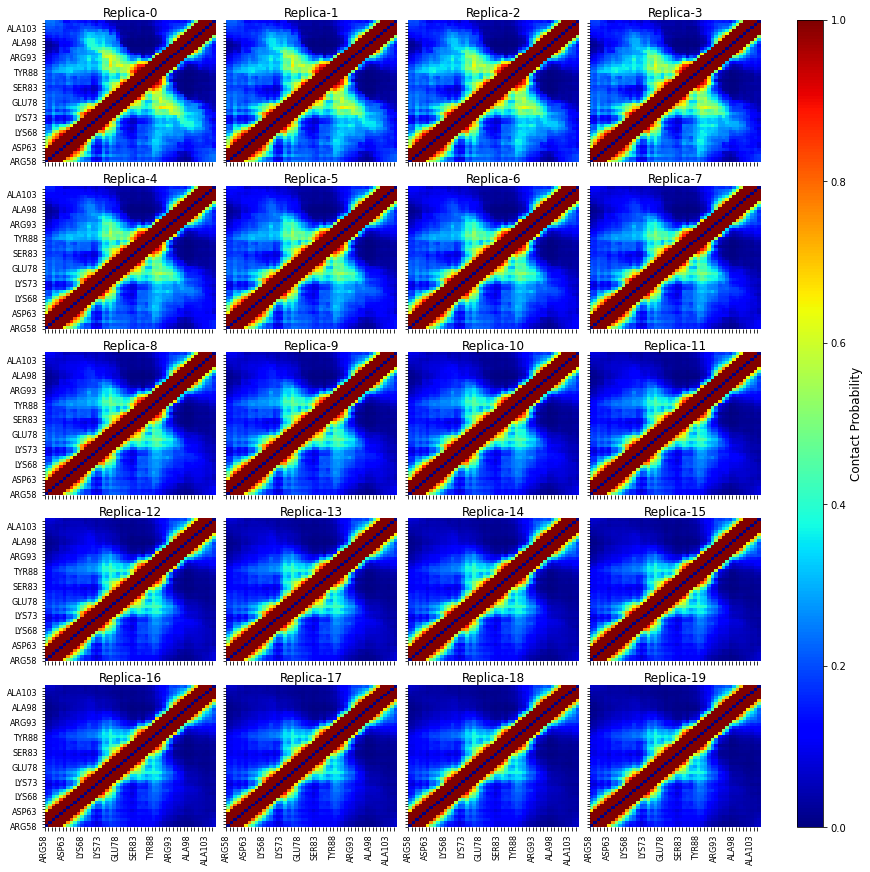

In [14]:
rep_keys = [f'rep:{i}' for i in range(20)]
create_subplots(rep_keys, outdir+'p_contact_maps_rep.png', 'Replica')


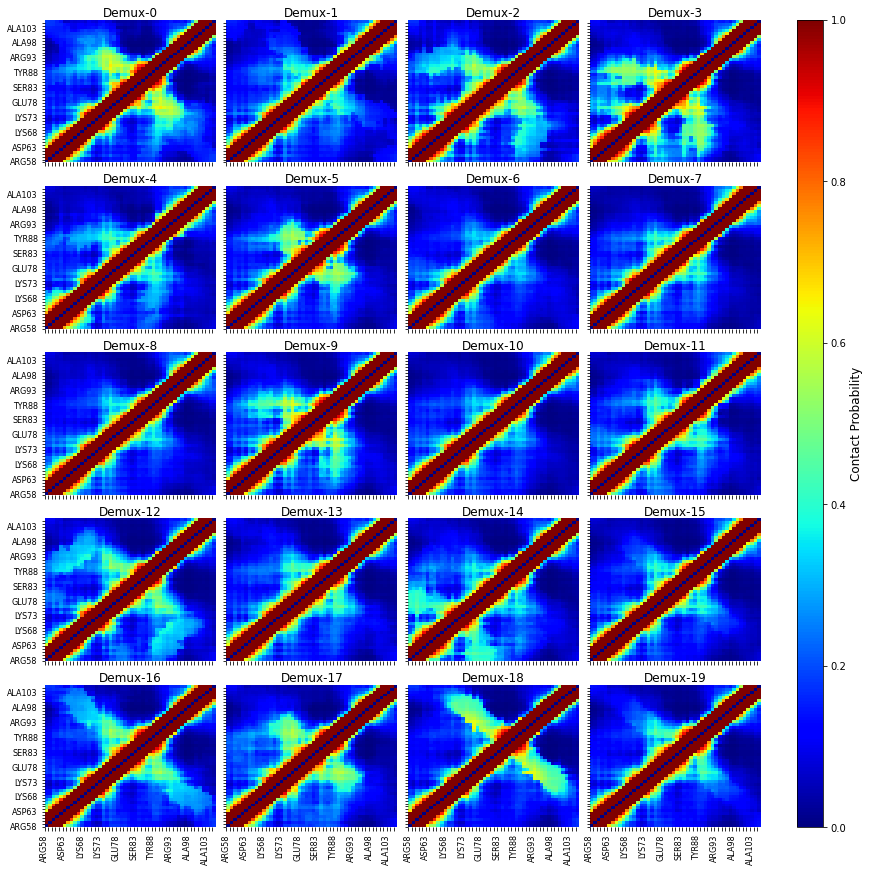

In [15]:
demux_keys = [f'demux:{i}' for i in range(20)]
create_subplots(demux_keys, outdir+'p_contact_maps_demux.png', 'Demux')

In [28]:
hc=json.load(open(dir+'/out_d/helix_contant.json','r'))
bsc=json.load(open(dir+'/out_d/sheet_contant.json','r'))
sa=json.load(open(dir+'/out_d/sa.json','r'))
rg=json.load(open(dir+'/out_d/rg.json','r'))

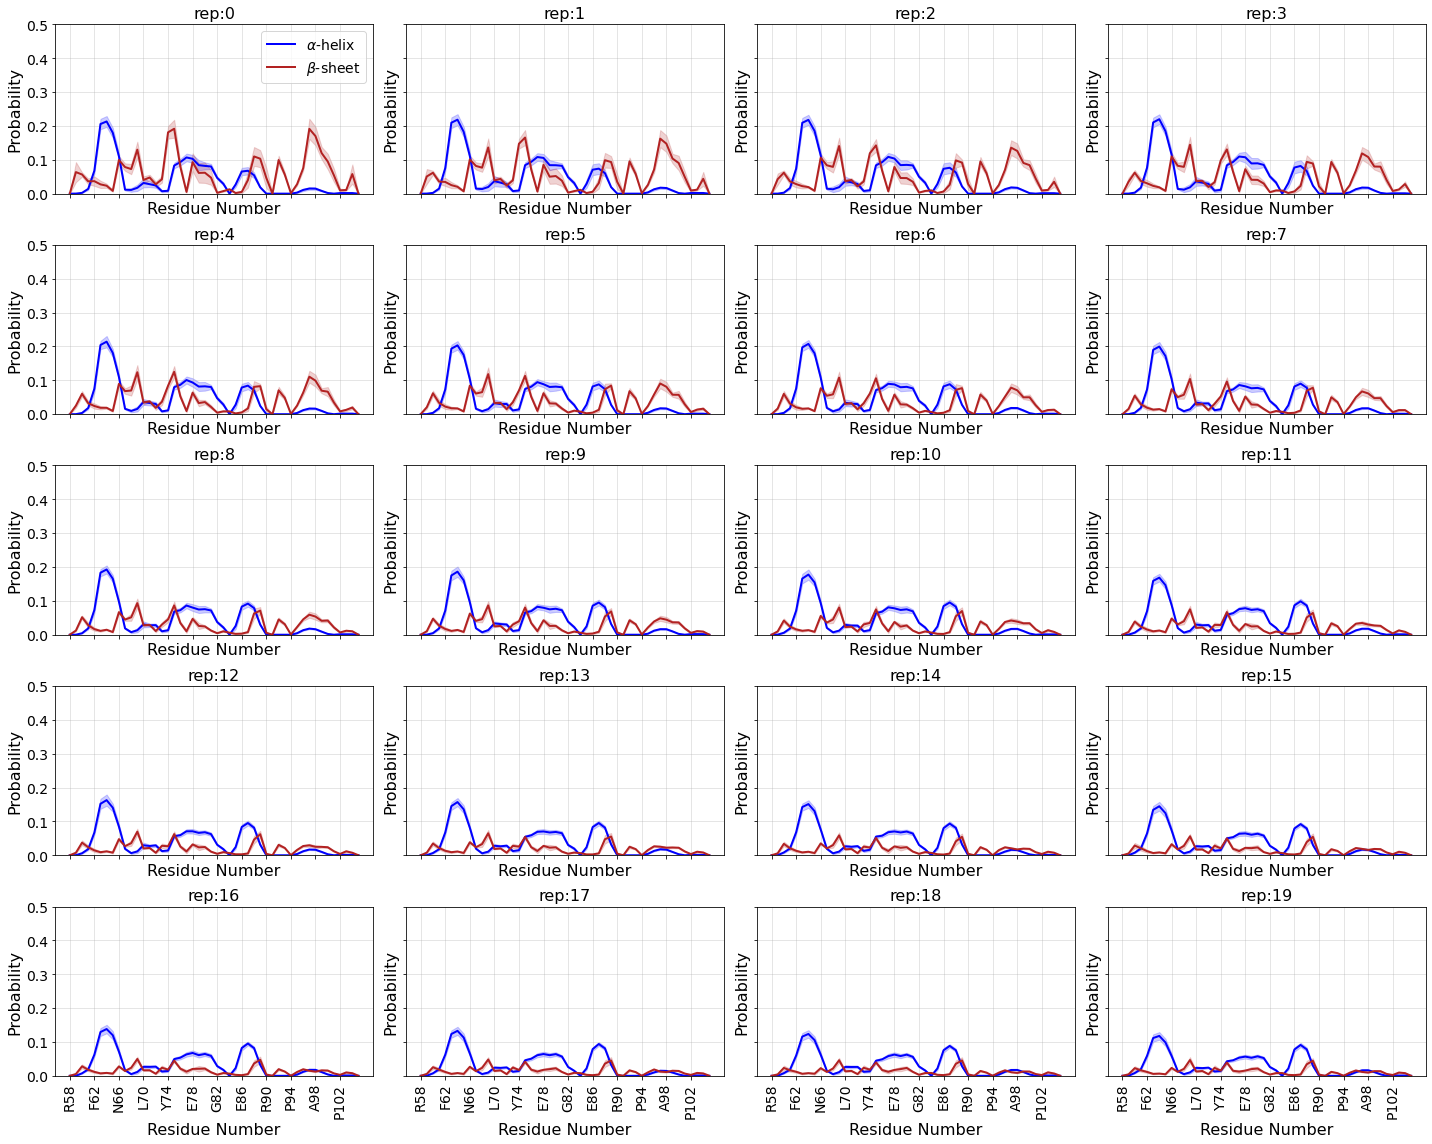

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Filter dictionaries to include only keys that start with 'rep:'
hc_replica = {key: hc[key] for key in hc if key.startswith('rep:')}
bsc_replica = {key: bsc[key] for key in bsc if key.startswith('rep:')}

# Extract keys for replicas
keys = list(hc_replica.keys())

# Determine number of columns and rows for subplots
ncol = 4
nrow = 5  # Adjust for number of items to plot

fig, ax = plt.subplots(nrow, ncol, sharex=True, sharey=True, figsize=(20, 16))
fig.subplots_adjust(hspace=0.5, wspace=0.2)  # Adjust spacing between subplots

# Define the spacing for x-ticks
n = 4  # Adjust this value to control the spacing of the x-ticks

for i, key in enumerate(keys):
    data_hc = np.array(hc_replica.get(key, np.zeros((48, 2))))  # Convert to numpy array
    data_bsc = np.array(bsc_replica.get(key, np.zeros((48, 2))))  # Convert to numpy array
    p, q = divmod(i, ncol)
    
    # Extracting data for helix content
    residues_hc = np.arange(1, 49)  # Assuming residues are from 1 to 48
    helix_content = data_hc[:, 0]
    helix_error = data_hc[:, 1]

    # Extracting data for beta sheet content
    residues_bsc = np.arange(1, 49)  # Assuming residues are from 1 to 48
    sheet_content = data_bsc[:, 0]
    sheet_error = data_bsc[:, 1]

    # Plotting helix content
    ax[p, q].plot(residues_hc, helix_content, linestyle='-', color='blue', lw=2, label=r'$\alpha$-helix')
    ax[p, q].fill_between(residues_hc, helix_content - helix_error, helix_content + helix_error, color='blue', alpha=0.2)

    # Plotting beta sheet content
    ax[p, q].plot(residues_bsc, sheet_content, linestyle='-', color='firebrick', lw=2, label=r'$\beta$-sheet')
    ax[p, q].fill_between(residues_bsc, sheet_content - sheet_error, sheet_content + sheet_error, color='firebrick', alpha=0.2)

    # Set plot properties
    ax[p, q].set_title(f'{key}', size=16)
    ax[p, q].set_xlabel('Residue Number', size=16)
    ax[p, q].set_ylabel('Probability', size=16)
    ax[p, q].grid(alpha=0.4)
    ax[p, q].tick_params(axis='both', which='major', labelsize=14)
    ax[p,q].set_ylim(0,0.5)
    
    # Set spaced x-ticks to full sequence in the last four plots
    if p == nrow - 1:  # Only for the last row of plots
        spaced_ticks = residues_hc[::n]
        spaced_labels = single_letter_sequence[::n]
        ax[p, q].set_xticks(spaced_ticks)
        ax[p, q].set_xticklabels(spaced_labels, rotation=90, fontsize=14)
    else:
        ax[p, q].set_xticks([])

# Add legend to the first plot (ax[0, 0])
ax[0, 0].legend(loc='upper right', fontsize=14)

# Adjust layout and save/show plot
plt.tight_layout()
plt.savefig(outdir+'secondary_structure_subplot_replicas.png', dpi=800)
plt.show()


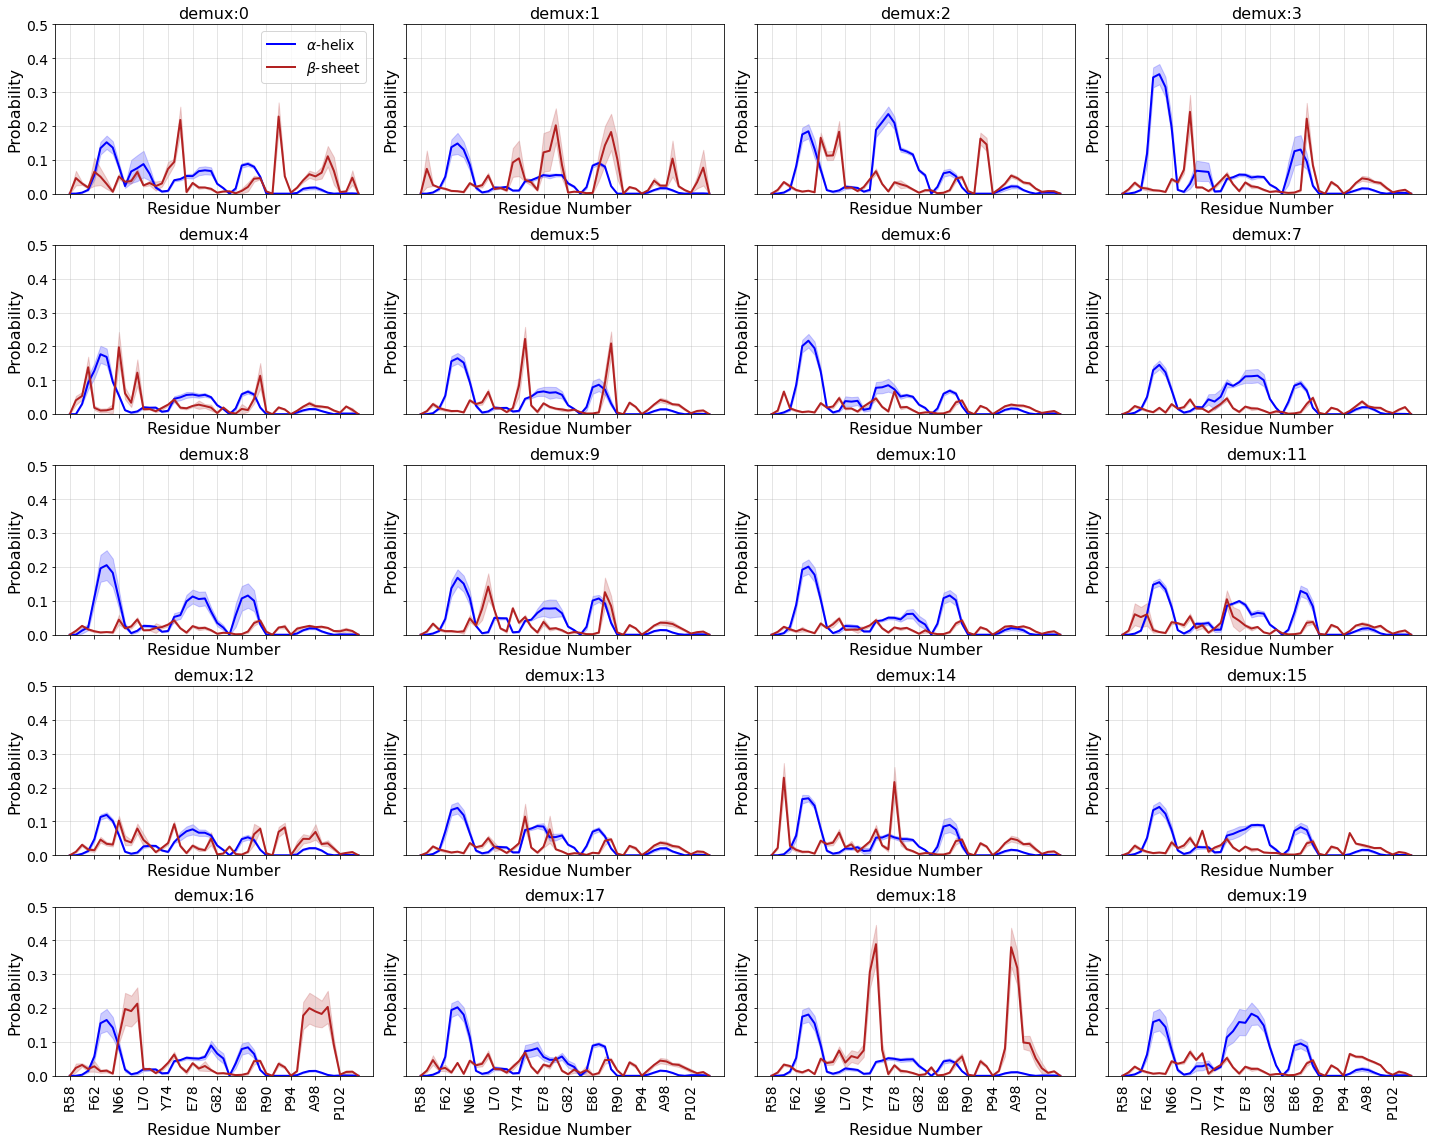

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Filter dictionaries to include only keys that start with 'rep:'
hc_replica = {key: hc[key] for key in hc if key.startswith('demux:')}
bsc_replica = {key: bsc[key] for key in bsc if key.startswith('demux:')}

# Extract keys for replicas
keys = list(hc_replica.keys())

# Determine number of columns and rows for subplots
ncol = 4
nrow = 5  # Adjust for number of items to plot

fig, ax = plt.subplots(nrow, ncol, sharex=True, sharey=True, figsize=(20, 16))
fig.subplots_adjust(hspace=0.5, wspace=0.2)  # Adjust spacing between subplots

# Define the spacing for x-ticks
n = 4  # Adjust this value to control the spacing of the x-ticks

for i, key in enumerate(keys):
    data_hc = np.array(hc_replica.get(key, np.zeros((48, 2))))  # Convert to numpy array
    data_bsc = np.array(bsc_replica.get(key, np.zeros((48, 2))))  # Convert to numpy array
    p, q = divmod(i, ncol)
    
    # Extracting data for helix content
    residues_hc = np.arange(1, 49)  # Assuming residues are from 1 to 48
    helix_content = data_hc[:, 0]
    helix_error = data_hc[:, 1]

    # Extracting data for beta sheet content
    residues_bsc = np.arange(1, 49)  # Assuming residues are from 1 to 48
    sheet_content = data_bsc[:, 0]
    sheet_error = data_bsc[:, 1]

    # Plotting helix content
    ax[p, q].plot(residues_hc, helix_content, linestyle='-', color='blue', lw=2, label=r'$\alpha$-helix')
    ax[p, q].fill_between(residues_hc, helix_content - helix_error, helix_content + helix_error, color='blue', alpha=0.2)

    # Plotting beta sheet content
    ax[p, q].plot(residues_bsc, sheet_content, linestyle='-', color='firebrick', lw=2, label=r'$\beta$-sheet')
    ax[p, q].fill_between(residues_bsc, sheet_content - sheet_error, sheet_content + sheet_error, color='firebrick', alpha=0.2)

    # Set plot properties
    ax[p, q].set_title(f'{key}', size=16)
    ax[p, q].set_xlabel('Residue Number', size=16)
    ax[p, q].set_ylabel('Probability', size=16)
    ax[p, q].grid(alpha=0.4)
    ax[p, q].tick_params(axis='both', which='major', labelsize=14)
    ax[p,q].set_ylim(0,0.5)
    
    
    
    # Set spaced x-ticks to full sequence in the last four plots
    if p == nrow - 1:  # Only for the last row of plots
        spaced_ticks = residues_hc[::n]
        spaced_labels = single_letter_sequence[::n]
        ax[p, q].set_xticks(spaced_ticks)
        ax[p, q].set_xticklabels(spaced_labels, rotation=90, fontsize=14)
    else:
        ax[p, q].set_xticks([])

# Add legend to the first plot (ax[0, 0])
ax[0, 0].legend(loc='upper right', fontsize=14)

# Adjust layout and save/show plot
plt.tight_layout()
plt.savefig(outdir+'secondary_structure_subplot_dmx.png', dpi=300)
plt.show()


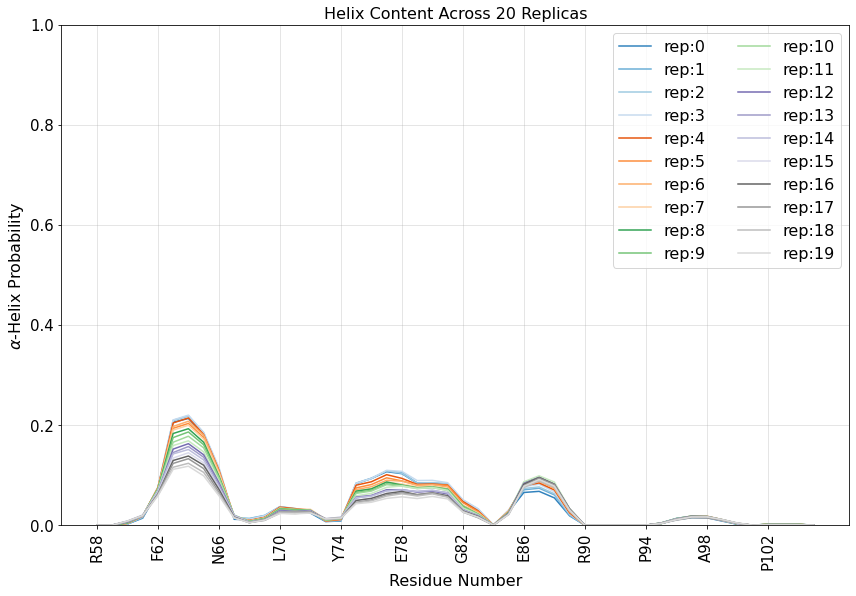

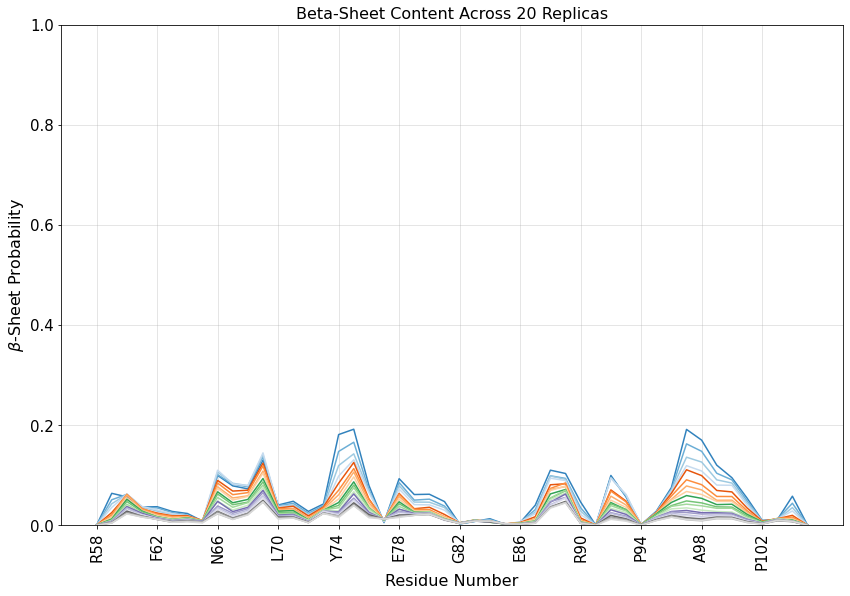

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Filter only 'rep:' keys
hc_replica = {key: hc[key] for key in hc if key.startswith('rep:')}
bsc_replica = {key: bsc[key] for key in bsc if key.startswith('rep:')}

# Sort keys numerically
keys = sorted(hc_replica.keys(), key=lambda x: int(x.split(':')[1]))

# Prepare residue indices (assuming 48 residues)
residues = np.arange(1, 49)

# ---------------------------
# 1️⃣ Helix content plot
# ---------------------------
plt.figure(figsize=(12, 8))
cmap = plt.cm.get_cmap('tab20c', len(keys))
colors = [cmap(i) for i in range(len(keys))]

for i, key in enumerate(keys):
    data = np.array(hc_replica[key])
    helix_content = data[:, 0]
    helix_error = data[:, 1]
    plt.plot(residues, helix_content, lw=1.5, color=colors[i], label=key)
    # plt.fill_between(residues, helix_content - helix_error, helix_content + helix_error,
    #                  color=colors[i], alpha=0.2)

plt.xlabel('Residue Number', fontsize=16)
plt.ylabel(r'$\alpha$-Helix Probability', fontsize=16)
plt.title('Helix Content Across 20 Replicas', fontsize=16)
#plt.legend(ncol=2, fontsize=16, title='Replica', title_fontsize=14, frameon=True)
plt.legend(ncol=2, fontsize=16,frameon=True)

plt.grid(alpha=0.4)
plt.tight_layout()
plt.ylim(0,1.0)
spaced_ticks = residues_hc[::4]
spaced_labels = single_letter_sequence[::4]
plt.xticks(ticks=spaced_ticks, labels=spaced_labels, rotation=90, fontsize=15)
plt.yticks(fontsize=15)
plt.savefig(outdir + 'helix_content_all_reps.png', dpi=800)
plt.show()

# ---------------------------
# 2️⃣ Beta-sheet content plot
# ---------------------------
plt.figure(figsize=(12, 8))
for i, key in enumerate(keys):
    data = np.array(bsc_replica[key])
    sheet_content = data[:, 0]
    sheet_error = data[:, 1]
    plt.plot(residues, sheet_content, lw=1.5, color=colors[i], label=key)
    # plt.fill_between(residues, sheet_content - sheet_error, sheet_content + sheet_error,
    #                  color=colors[i], alpha=0.2)

plt.xlabel('Residue Number', fontsize=16)
plt.ylabel(r'$\beta$-Sheet Probability', fontsize=16)
plt.title('Beta-Sheet Content Across 20 Replicas', fontsize=16)
# plt.legend(ncol=2, fontsize=10, title='Replica', title_fontsize=11, frameon=False)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.ylim(0,1.0)
plt.yticks(fontsize=15)
spaced_ticks = residues_hc[::4]
spaced_labels = single_letter_sequence[::4]
plt.xticks(ticks=spaced_ticks, labels=spaced_labels, rotation=90, fontsize=15)
plt.savefig(outdir + 'sheet_content_all_reps.png', dpi=800)
plt.show()


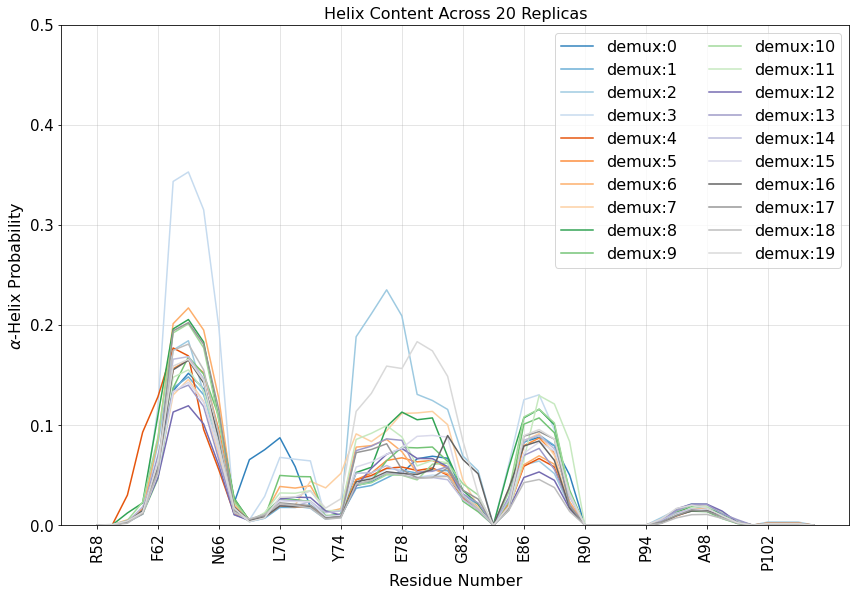

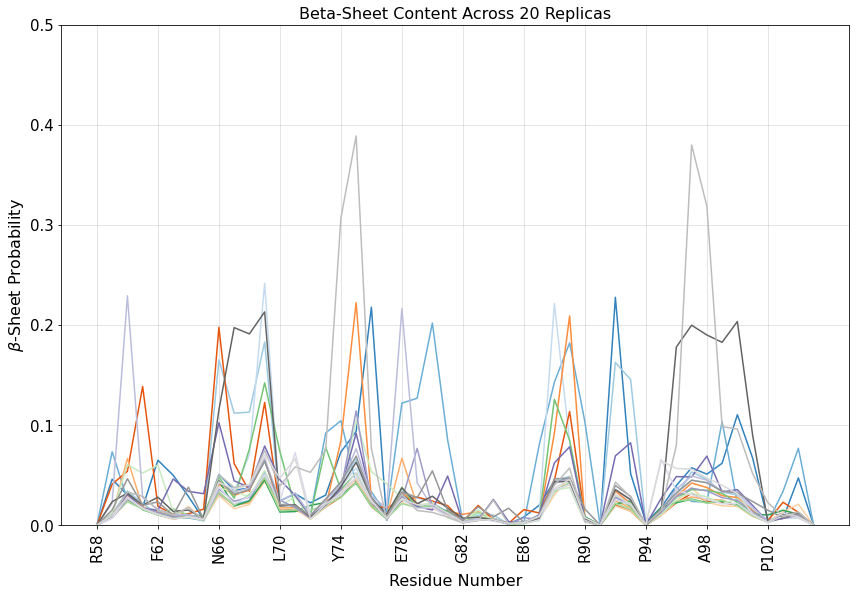

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Filter only 'rep:' keys
hc_replica = {key: hc[key] for key in hc if key.startswith('demux:')}
bsc_replica = {key: bsc[key] for key in bsc if key.startswith('demux:')}

# Sort keys numerically
keys = sorted(hc_replica.keys(), key=lambda x: int(x.split(':')[1]))

# Prepare residue indices (assuming 48 residues)
residues = np.arange(1, 49)

# ---------------------------
# 1️⃣ Helix content plot
# ---------------------------
plt.figure(figsize=(12, 8))
cmap = plt.cm.get_cmap('tab20c', len(keys))
colors = [cmap(i) for i in range(len(keys))]

for i, key in enumerate(keys):
    data = np.array(hc_replica[key])
    helix_content = data[:, 0]
    helix_error = data[:, 1]
    plt.plot(residues, helix_content, lw=1.5, color=colors[i], label=key)
    # plt.fill_between(residues, helix_content - helix_error, helix_content + helix_error,
    #                  color=colors[i], alpha=0.2)

plt.xlabel('Residue Number', fontsize=16)
plt.ylabel(r'$\alpha$-Helix Probability', fontsize=16)
plt.title('Helix Content Across 20 Replicas', fontsize=16)
#plt.legend(ncol=2, fontsize=16, title='Replica', title_fontsize=14, frameon=True)
plt.legend(ncol=2, fontsize=16,frameon=True, loc='upper right')

plt.grid(alpha=0.4)
plt.tight_layout()
plt.ylim(0,0.5)
spaced_ticks = residues_hc[::4]
spaced_labels = single_letter_sequence[::4]
plt.xticks(ticks=spaced_ticks, labels=spaced_labels, rotation=90, fontsize=15)
plt.yticks(fontsize=15)
plt.savefig(outdir + 'helix_content_all_reps.png', dpi=800)
plt.show()

# ---------------------------
# 2️⃣ Beta-sheet content plot
# ---------------------------
plt.figure(figsize=(12, 8))
for i, key in enumerate(keys):
    data = np.array(bsc_replica[key])
    sheet_content = data[:, 0]
    sheet_error = data[:, 1]
    plt.plot(residues, sheet_content, lw=1.5, color=colors[i], label=key)
    # plt.fill_between(residues, sheet_content - sheet_error, sheet_content + sheet_error,
    #                  color=colors[i], alpha=0.2)

plt.xlabel('Residue Number', fontsize=16)
plt.ylabel(r'$\beta$-Sheet Probability', fontsize=16)
plt.title('Beta-Sheet Content Across 20 Replicas', fontsize=16)
# plt.legend(ncol=2, fontsize=10, title='Replica', title_fontsize=11, frameon=False)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.ylim(0,0.5)
plt.yticks(fontsize=15)
spaced_ticks = residues_hc[::4]
spaced_labels = single_letter_sequence[::4]
plt.xticks(ticks=spaced_ticks, labels=spaced_labels, rotation=90, fontsize=15)
plt.savefig(outdir + 'sheet_content_all_reps.png', dpi=800)
plt.show()


In [20]:
import matplotlib.pyplot as plt
import numpy as np

def pmf1d(x, nbins, range=None, weights=None, return_bin_centers=True):
    count, edge = np.histogram(x, bins=nbins, range=range, weights=weights)
    if weights is None:
        p = count / len(x)
    else:
        p = count
    if return_bin_centers:
        return p, edge[:-1] + np.diff(edge) / 2
    else:
        return p



# Function to plot subplots
def plot_rg_subplots(keys, nbins=50):
    ncol = 4
    nrow = 5 # Calculate number of rows needed
    fig, axes = plt.subplots(nrow, ncol, figsize=(20, 20))

    for i, key in enumerate(keys):
        x = rg[key]  # Assuming rg[key] gives the data for each key
        p, bc = pmf1d(x, nbins=nbins)

        row_idx = i // ncol
        col_idx = i % ncol
        ax = axes[row_idx, col_idx]

        ax.plot(bc, p)
        ax.fill_between(bc, p, alpha=0.3, label='Rg Probability')
        ax.set_title(key, fontsize=16)
        ax.set_xlabel('Radius of Gyration [nm]', fontsize=14)
        ax.set_ylabel('Probability', fontsize=14)
        ax.legend(loc='upper right', fontsize=12)

    plt.tight_layout()
    plt.savefig('%s/Rg_probabilities_subplots.pdf' % outdir, bbox_inches='tight')
    plt.show()



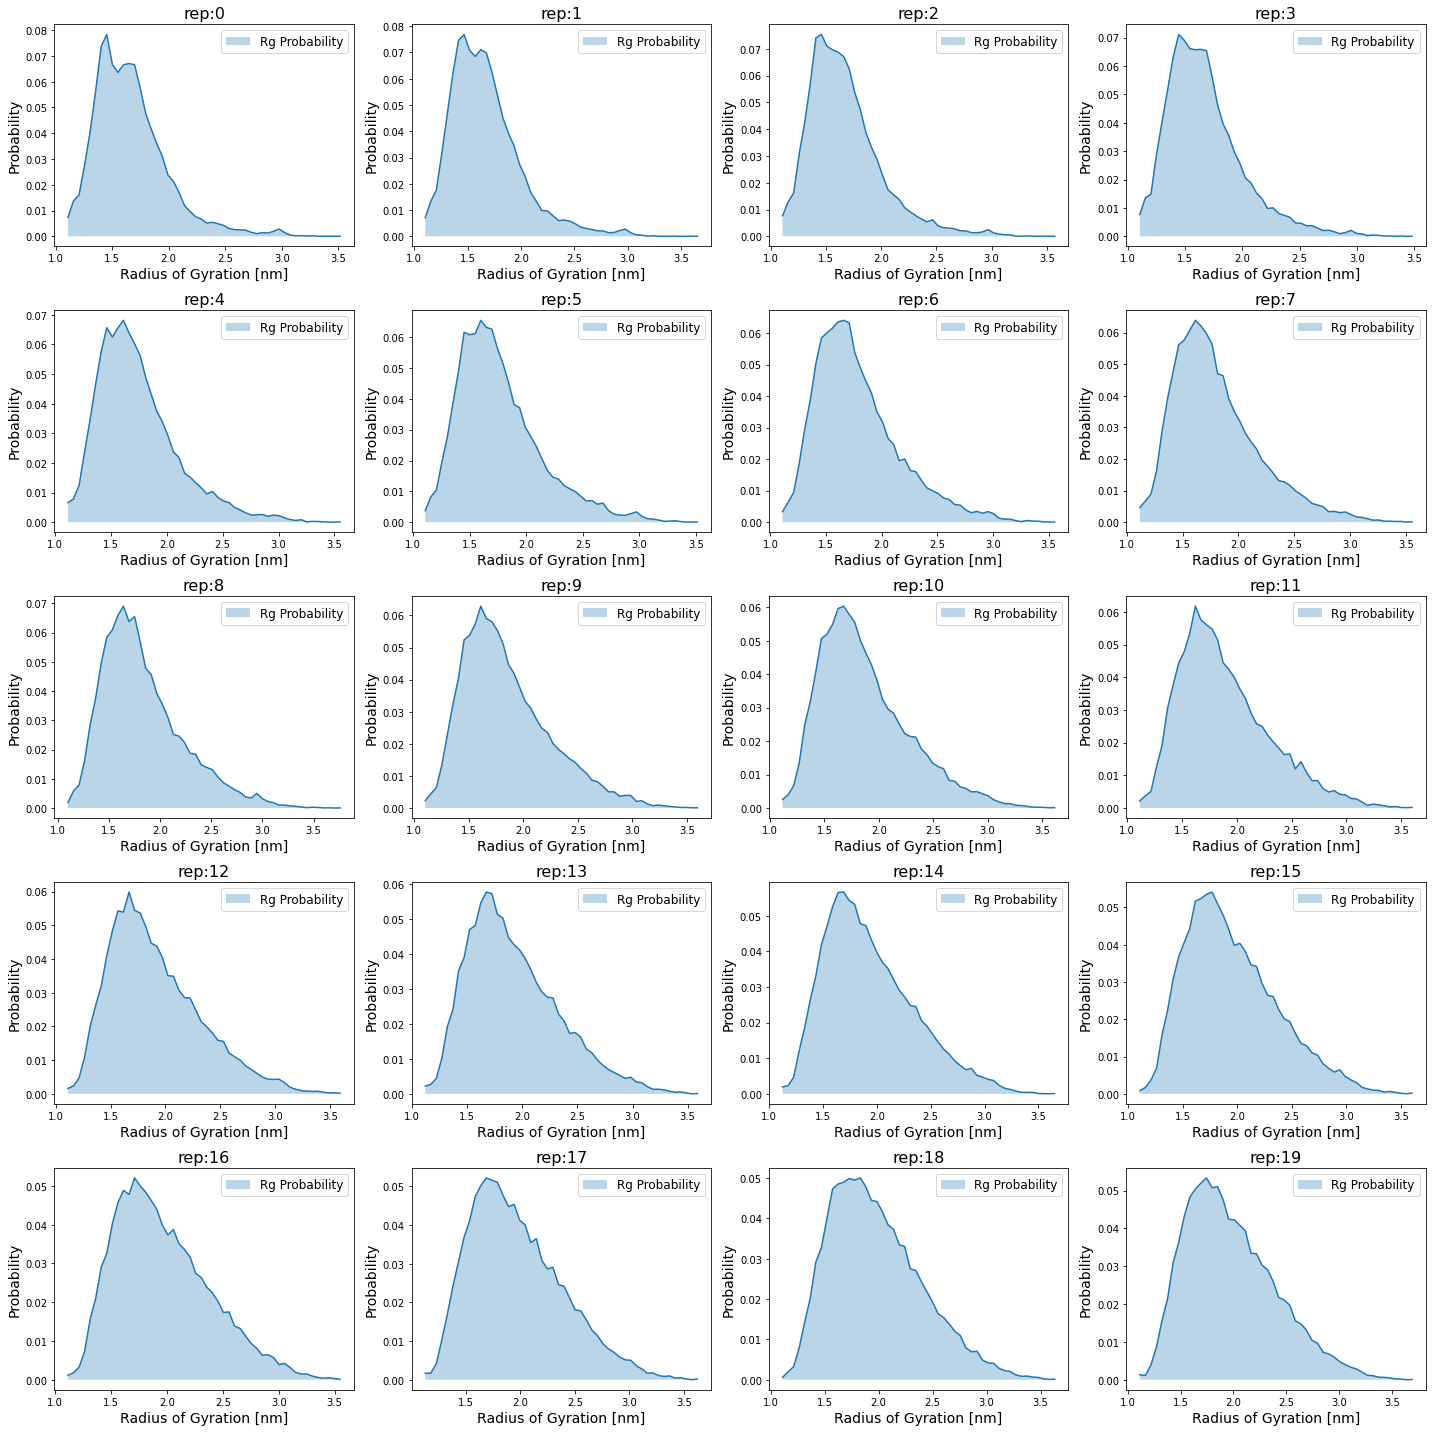

In [21]:
rg_keys_rep = [key for key in rg.keys() if key.startswith('rep:')]
plot_rg_subplots(rg_keys_rep)

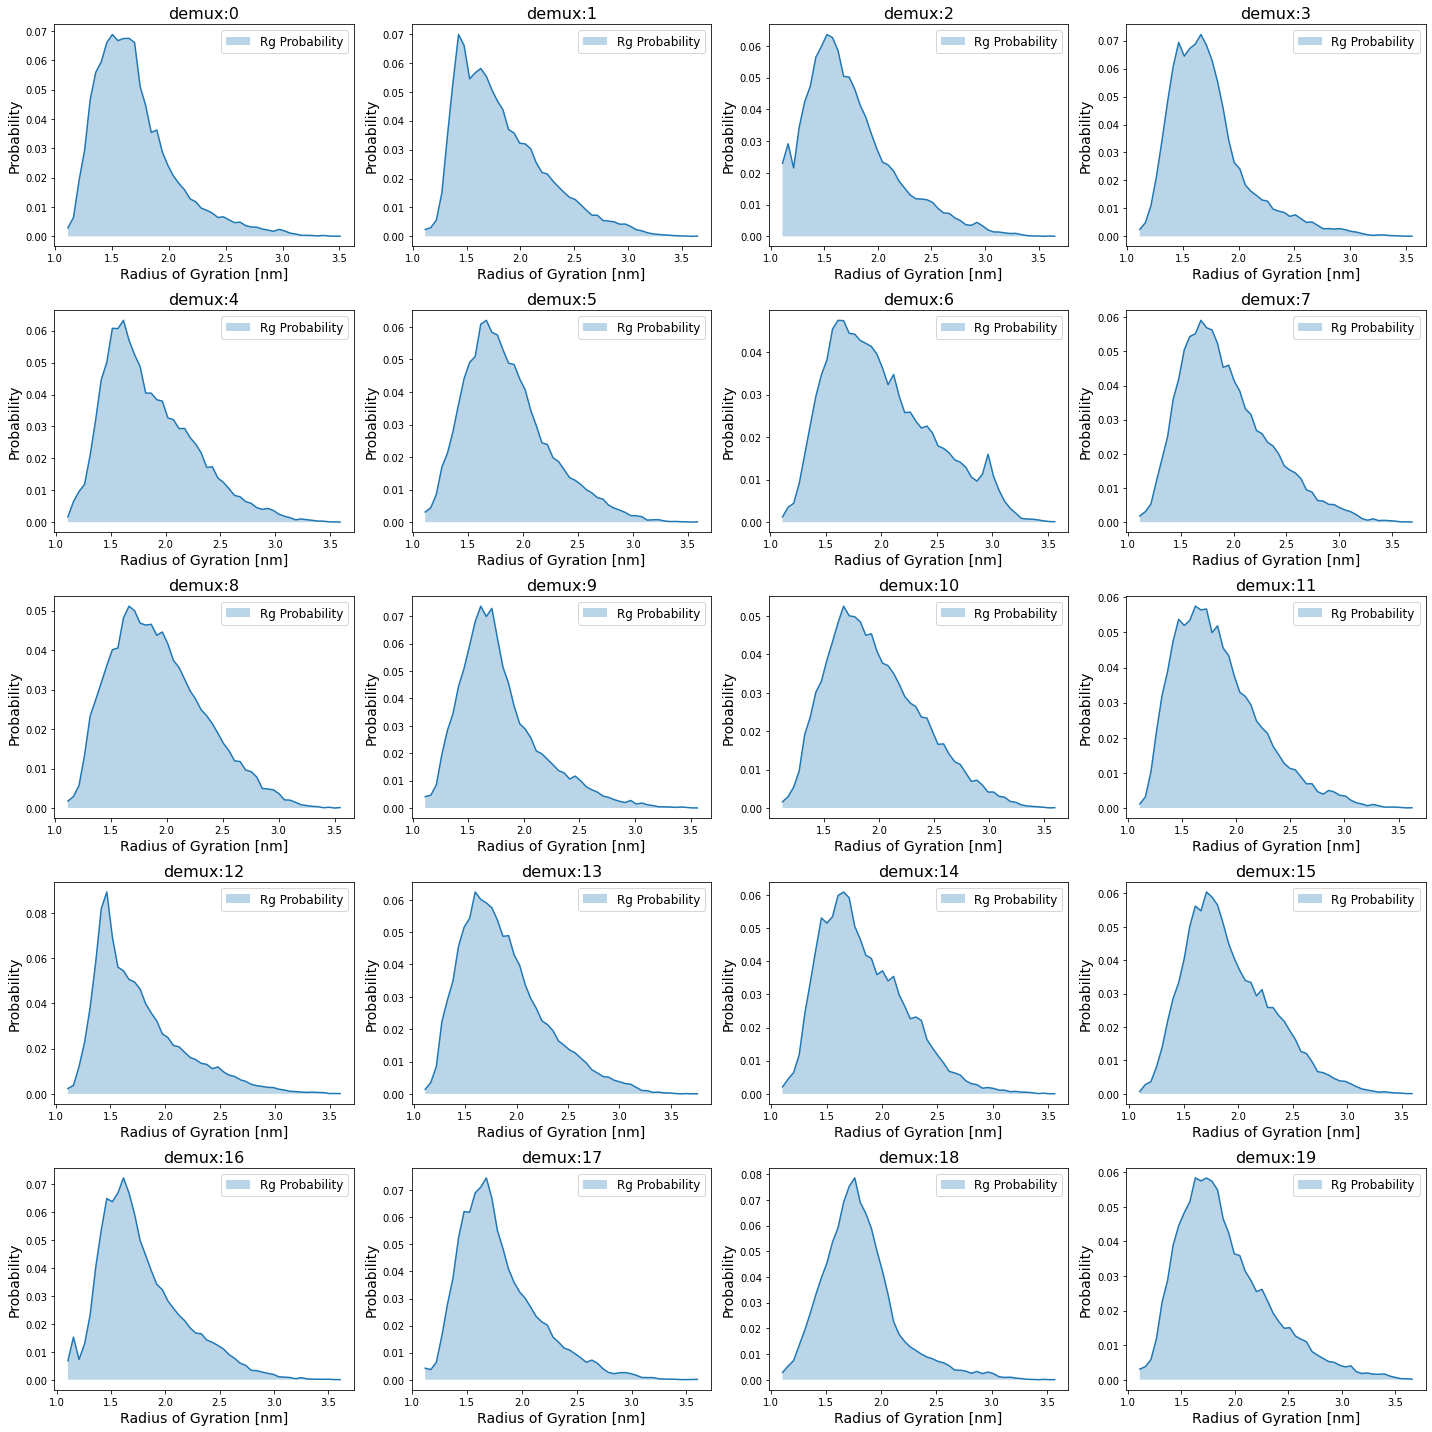

In [22]:
def pmf1d(x, nbins, range=None, weights=None, return_bin_centers=True):
    count, edge = np.histogram(x, bins=nbins, range=range, weights=weights)
    if weights is None:
        p = count / len(x)
    else:
        p = count
    if return_bin_centers:
        return p, edge[:-1] + np.diff(edge) / 2
    else:
        return p



# Function to plot subplots
def plot_rg_subplots(keys, nbins=50):
    ncol = 4
    nrow = 5 # Calculate number of rows needed
    fig, axes = plt.subplots(nrow, ncol, figsize=(20, 20))

    for i, key in enumerate(keys):
        x = rg[key]  # Assuming rg[key] gives the data for each key
        p, bc = pmf1d(x, nbins=nbins)

        row_idx = i // ncol
        col_idx = i % ncol
        ax = axes[row_idx, col_idx]

        ax.plot(bc, p)
        ax.fill_between(bc, p, alpha=0.3, label='Rg Probability')
        ax.set_title(key, fontsize=16)
        ax.set_xlabel('Radius of Gyration [nm]', fontsize=14)
        ax.set_ylabel('Probability', fontsize=14)
        ax.legend(loc='upper right', fontsize=12)

    plt.tight_layout()
    plt.savefig('%s/Rg_probabilities_subplots_dmx.pdf' % outdir, bbox_inches='tight')
    plt.show()

rg_keys_rep = [key for key in rg.keys() if key.startswith('demux:')]
plot_rg_subplots(rg_keys_rep)

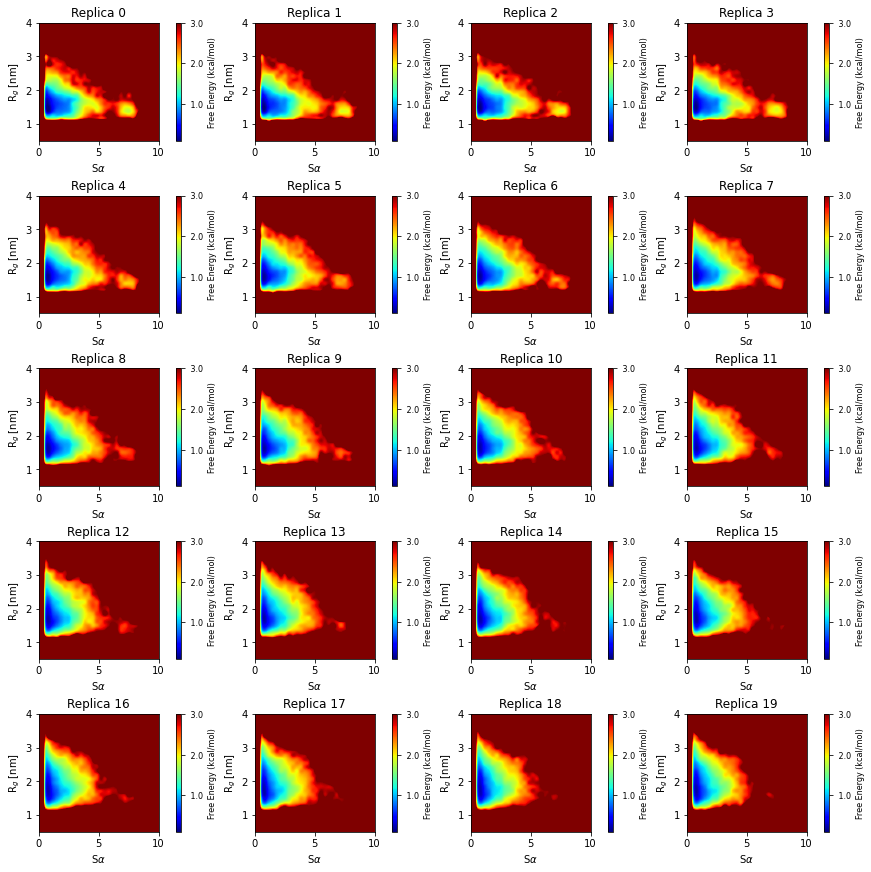

<Figure size 432x288 with 0 Axes>

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def plot_Rg_vs_Sa_subplot(ax, a, b, T, y0, ymax, x0, xmax, weight=None, title=""):
    # Calculate free energy
    free_energy, xedges, yedges = np.histogram2d(
        a, b, bins=30, range=[[y0, ymax], [x0, xmax]], density=True, weights=weight)
    free_energy = np.log(np.flipud(free_energy) + 0.000001)
    free_energy = -(0.001987 * T) * free_energy

    # Define the color scale limits
    vmin, vmax = 0.1, 3.0  # Ensures the colorbar is capped at 3 kcal/mol
    cbar_ticks = [0, 1, 2, 3]

    # Plot heatmap with color limits
    im = ax.imshow(free_energy, interpolation='gaussian', extent=[yedges[0], yedges[-1], xedges[0], xedges[-1]],
                   cmap='jet', aspect='auto', vmin=vmin, vmax=vmax)
    
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(r"S$\alpha$", fontsize=10)
    ax.set_ylabel(r"R$_g$ [nm]", fontsize=10)

    # Add colorbar with proper limits
    cbar = plt.colorbar(im, ax=ax, ticks=cbar_ticks, format='% .1f')
    cbar.set_label("Free Energy (kcal/mol)", fontsize=8)
    cbar.ax.tick_params(labelsize=8)

# Define parameters
T = 300
y0, ymax = 0.5, 4.0
x0, xmax = 0.0, 10.0

# Create subplots
fig, axes = plt.subplots(5, 4, figsize=(12, 12), constrained_layout=True)
axes = axes.flatten()

# Loop through replicas
for i in range(20):
    rep_key = f'rep:{i}'
    sa_i = np.asarray(sa[rep_key])
    sa_total = np.sum(sa_i, axis=0)  # Summing over the 43 lists for each frame
    plot_Rg_vs_Sa_subplot(axes[i], rg[rep_key], sa_total, T, y0, ymax, x0, xmax, title=f"Replica {i}")

plt.show()
plt.savefig(outdir+'da_v_rg_rep.png', dpi=800)


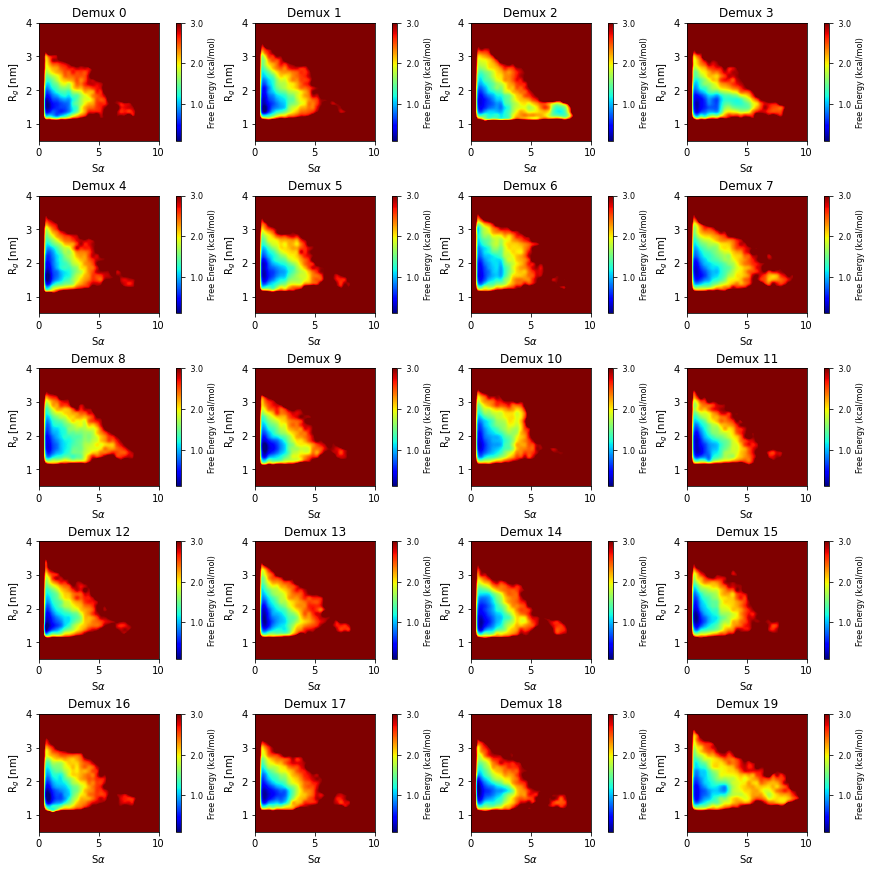

<Figure size 432x288 with 0 Axes>

In [24]:
# Define parameters
T = 300
y0, ymax = 0.5, 4.0
x0, xmax = 0.0, 10.0

# Create subplots
fig, axes = plt.subplots(5, 4, figsize=(12, 12), constrained_layout=True)
axes = axes.flatten()

# Loop through replicas
for i in range(20):
    rep_key = f'demux:{i}'
    sa_i = np.asarray(sa[rep_key])
    sa_total = np.sum(sa_i, axis=0)  # Summing over the 43 lists for each frame
    plot_Rg_vs_Sa_subplot(axes[i], rg[rep_key], sa_total, T, y0, ymax, x0, xmax, title=f"Demux {i}")

plt.show()
plt.savefig(outdir+'sa_v_rg_dmx.png', dpi=800)

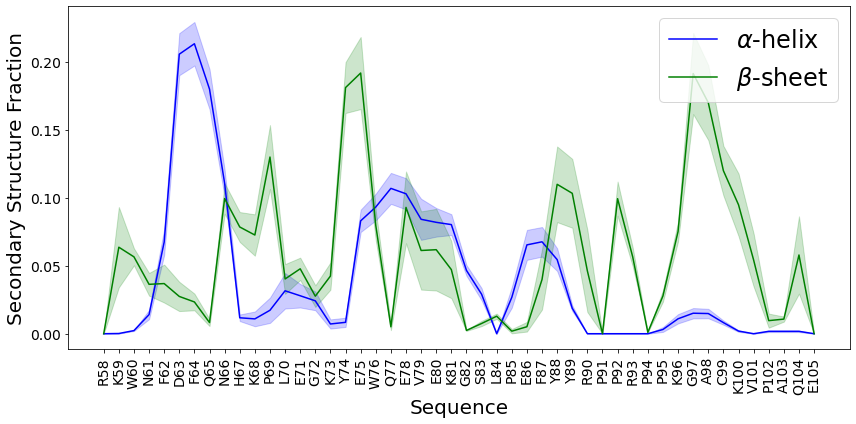

In [25]:
hc = json.load(open(dir+'/out_d/helix_contant.json','r'))
hc = np.asarray(hc['rep:0'])

bsc = json.load(open(dir+'/out_d/sheet_contant.json','r'))
bsc = np.asarray(bsc['rep:0'])


hc_probabilities = hc[:, 0]
hc_errors = hc[:, 1]

bsc_probabilities = bsc[:, 0]
bsc_errors = bsc[:, 1]


plt.figure(figsize=(12, 6))


plt.plot(single_letter_sequence, hc_probabilities, label=r'$\alpha$-helix', color='blue')
plt.fill_between(single_letter_sequence, hc_probabilities - hc_errors, hc_probabilities + hc_errors, color='blue', alpha=0.2)


plt.plot(single_letter_sequence, bsc_probabilities, label=r'$\beta$-sheet', color='green')
plt.fill_between(single_letter_sequence, bsc_probabilities - bsc_errors, bsc_probabilities + bsc_errors, color='green', alpha=0.2)


plt.xticks(ticks=np.arange(len(single_letter_sequence)), labels=single_letter_sequence, rotation=90, size=14)


plt.yticks(fontsize=14)  


plt.xlabel('Sequence', size=20)
plt.ylabel('Secondary Structure Fraction', size=20)
# plt.title('Alpha-Helical and Beta-Sheet Content')
plt.legend(fontsize=24, loc='upper right', bbox_to_anchor=(1, 1))


plt.tight_layout()
plt.savefig(outdir + '/ss.png', dpi=1200)

plt.show()

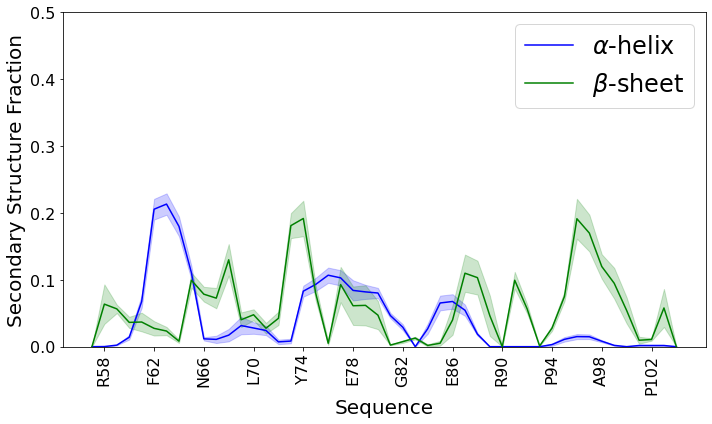

In [26]:
hc = json.load(open(dir+'/out_d/helix_contant.json','r'))
hc = np.asarray(hc['rep:0'])

bsc = json.load(open(dir+'/out_d/sheet_contant.json','r'))
bsc = np.asarray(bsc['rep:0'])


hc_probabilities = hc[:, 0]
hc_errors = hc[:, 1]

bsc_probabilities = bsc[:, 0]
bsc_errors = bsc[:, 1]


plt.figure(figsize=(10, 6))


plt.plot(single_letter_sequence, hc_probabilities, label=r'$\alpha$-helix', color='blue')
plt.fill_between(single_letter_sequence, hc_probabilities - hc_errors, hc_probabilities + hc_errors, color='blue', alpha=0.2)


plt.plot(single_letter_sequence, bsc_probabilities, label=r'$\beta$-sheet', color='green')
plt.fill_between(single_letter_sequence, bsc_probabilities - bsc_errors, bsc_probabilities + bsc_errors, color='green', alpha=0.2)



spaced_ticks = residues_hc[::4]
spaced_labels = single_letter_sequence[::4]
plt.xticks(ticks=spaced_ticks, labels=spaced_labels, rotation=90, fontsize=16)
# plt.xticks(ticks=np.arange(len(single_letter_sequence)), labels=single_letter_sequence, rotation=90, size=14)


plt.yticks(fontsize=16)  


plt.xlabel('Sequence', size=20)
plt.ylabel('Secondary Structure Fraction', size=20)
# plt.title('Alpha-Helical and Beta-Sheet Content')
plt.legend(fontsize=24, loc='upper right', bbox_to_anchor=(1, 1))
plt.ylim(0,0.5)


plt.tight_layout()
plt.savefig(outdir + '/ss.png', dpi=1200)

plt.show()

In [27]:

# file_path='./'
# xvg_files = [ 'replica_temp.xvg', 'replica_index.xvg']

# xvg_temp=np.loadtxt(f'{file_path}/{xvg_files[0]}', comments=['#','@'])
# xvg_index=np.loadtxt(f'{file_path}/{xvg_files[1]}', comments=['#','@'])

In [28]:
# # Probabilities of replica visiting the base or zeroth replica
# prob=[]
# b=0
# for i in range(nrep):
#     a=(np.where(xvg_temp.T[0+1]==i)[0].shape[0])/(xvg_temp.shape[0])
#     prob.append(a)
#     print(i,a)
#     b=b+a
# print(f'Probability check : {b}')

In [29]:
# r2_temp=temperature

# # Mean effective temperature of each respective replica

# T_mean=[]

# for j in range(nrep+1):
#     replica_T=[]
#     for i in xvg_index.T[j]:
#         replica_T.append(float(r2_temp[int(i)]))
#     T_mean.append(np.mean(replica_T))

In [30]:
# # Compute Round Trip Times
# def calc_round_trip_stack_2(file, nreps=20, dt=0.002, rep_ex=800, freq=True):
    
#     n=0
#     rep_dict={}
#     rep=[i for i in range(nreps)]
#     data=np.loadtxt(file ,comments=["@", "#"])[:,1:]
#     min_rep=0; max_rep=nreps
#     min_rep_flip=False ; max_rep_flip=False

#     for i in rep:
#         rep_dict[i] = 0
#         # stack = []
#         for e in data.T[i]:
#             n+=1
#             # if int(e) not in stack:
#             #     stack.append(int(e))

#             if int(e) == min_rep : min_rep_flip=True
#             if int(e) == max_rep : max_rep_flip=True

#             if int(e) == i and min_rep_flip and max_rep_flip :
#                 max_rep_flip=False
#                 min_rep_flip=False
#                 rep_dict[i]+=1
#                 # stack = []

#         if freq : rep_dict[i] = 1/(rep_dict[i]*dt*rep_ex*10**-3)
#         else : rep_dict[i] = rep_dict[i]*dt*rep_ex*10**-3   

#     return rep_dict

In [31]:
# rt_dict=calc_round_trip_stack_2(f'{file_path}/{xvg_files[0]}',nreps=20)

In [32]:
# fig, ax = plt.subplots(3,1, figsize=(15,15), sharex=True)

# ax[0].tick_params(axis='y', labelsize=28)
# ax[0].bar(range(nrep),prob,width = 0.4, color='k')
# ax[0].set_yticks(np.arange(0,0.16,0.04),np.arange(0,0.16,0.04))
# ax[0].set_ylabel(r'$P(T_{0})$', size=25, labelpad=10)
# ax[1].tick_params(axis='y', labelsize=28)
# ax[1].bar(range(nrep),T_mean,width = 0.4, color='k')
# ax[1].set_yticks(range(0,600,200),range(0,600,200))
# ax[1].set_ylabel(r'$<T> \;K$', size=25, labelpad=10)

# ax[0].tick_params(top=False, bottom=False,
#                 labeltop=False, labelbottom=False)
# ax[1].tick_params(top=False, bottom=False,
#                 labeltop=False, labelbottom=False)
# ax[2].tick_params(top=False, bottom=True,
#                 labeltop=False, labelbottom=True)
# ax[2].tick_params(axis='x', labelsize=28)
# ax[2].tick_params(axis='y', labelsize=28)
# for keys in rt_dict.keys():
#     ax[2].bar(keys,rt_dict[keys],width = 0.4, color='k')

# ax[2].set_xticks(range(nrep),range(nrep))
# # ax[2].set_yticks(range(0,1500,500),range(0,1500,500))
# ax[2].set_ylabel(f"Round \nTrip (ns)", size=25, labelpad=10)
# ax[2].set_xlabel('Replica Number', size=25, labelpad=10)

# plt.tight_layout()
# # This part of the code is adding text labels to each subplot in the figure.

# # sub_fig_labels=['a)', 'b)', 'c)']
# # y_pos = [0.14, 420, 6]

# # for i in range(3):
# #     ax[i].text(-3.8, y_pos[i], sub_fig_labels[i], size=25)

In [33]:
rg_300K = np.asarray(rg['rep:0'])

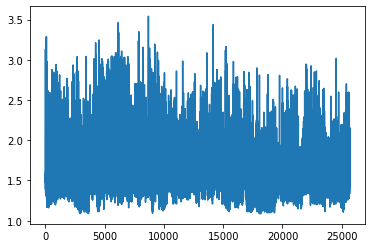

In [34]:
plt.plot(rg_300K)

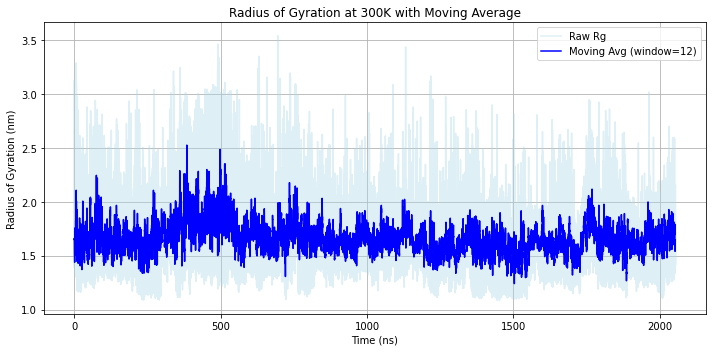

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
frame_interval_ps = 80
frame_interval_ns = frame_interval_ps / 1000
time = np.arange(len(rg_300K)) * frame_interval_ns

# Set the window size in frames (e.g., 1 ns window → 12 frames)
window_size = 12

# Moving average using convolution
rg_smoothed = np.convolve(rg_300K, np.ones(window_size)/window_size, mode='valid')

# Adjust time axis for smoothed data
time_smoothed = time[:len(rg_smoothed)]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(time, rg_300K, alpha=0.4, label='Raw Rg', color='lightblue')
plt.plot(time_smoothed, rg_smoothed, label=f'Moving Avg (window={window_size})', color='blue')
plt.xlabel('Time (ns)')
plt.ylabel('Radius of Gyration (nm)')
plt.title('Radius of Gyration at 300K with Moving Average')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/Users/kaushikborthakur1211/opt/anaconda3/envs/New_env/lib/python3.7/site-packages/ipykernel_launcher.py:9: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  if __name__ == '__main__':


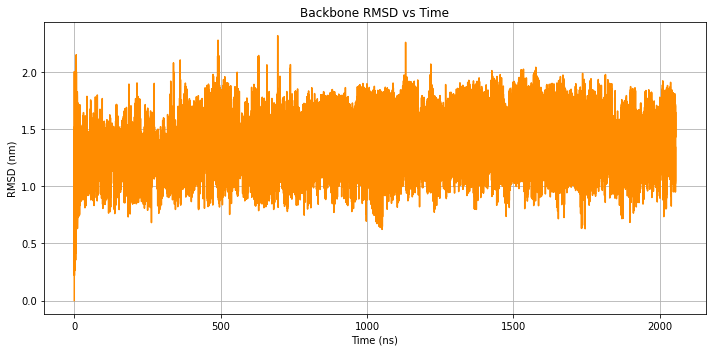

In [36]:
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

# Align all frames in the trajectory to the first frame using backbone atoms
trj.superpose(trj[0], atom_indices=trj.topology.select('backbone'))

# Compute RMSD with respect to the first frame
rmsd = md.rmsd(trj, trj[0], atom_indices=trj.topology.select('backbone'))

# Create time axis (frames saved every 80 ps)
frame_interval_ps = 80
frame_interval_ns = frame_interval_ps / 1000
time = np.arange(len(rmsd)) * frame_interval_ns

# Plot RMSD vs Time
plt.figure(figsize=(10, 5))
plt.plot(time, rmsd, color='darkorange')
plt.xlabel('Time (ns)')
plt.ylabel('RMSD (nm)')
plt.title('Backbone RMSD vs Time')
plt.grid(True)
plt.tight_layout()
plt.show()


/Users/kaushikborthakur1211/opt/anaconda3/envs/New_env/lib/python3.7/site-packages/ipykernel_launcher.py:9: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  if __name__ == '__main__':


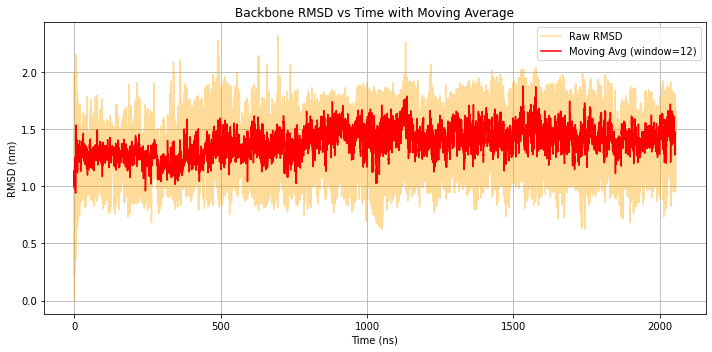

In [37]:
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

# Align trajectory to the first frame using backbone atoms
trj.superpose(trj[0], atom_indices=trj.topology.select('backbone'))

# Compute RMSD with respect to the first frame
rmsd = md.rmsd(trj, trj[0], atom_indices=trj.topology.select('backbone'))

# Time axis (frames saved every 80 ps)
frame_interval_ps = 80
frame_interval_ns = frame_interval_ps / 1000
time = np.arange(len(rmsd)) * frame_interval_ns

# Set window size for smoothing (e.g., 1 ns = 12 frames if 80 ps/frame)
window_size = 12

# Compute moving average of RMSD
rmsd_smooth = np.convolve(rmsd, np.ones(window_size)/window_size, mode='valid')
time_smooth = time[:len(rmsd_smooth)]  # adjust time axis accordingly

# Plot
plt.figure(figsize=(10, 5))
plt.plot(time, rmsd, color='orange', alpha=0.4, label='Raw RMSD')
plt.plot(time_smooth, rmsd_smooth, color='red', label=f'Moving Avg (window={window_size})')
plt.xlabel('Time (ns)')
plt.ylabel('RMSD (nm)')
plt.title('Backbone RMSD vs Time with Moving Average')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


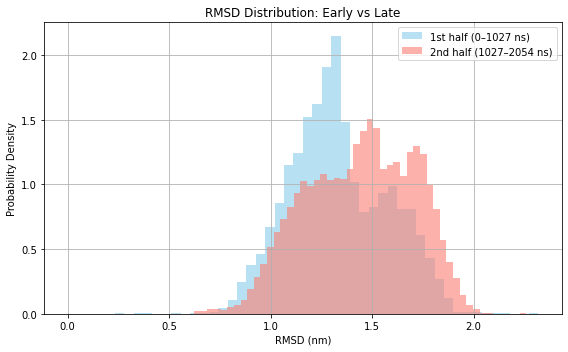

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Assume `rmsd` and `time` already exist from earlier RMSD calculation
# Define split point (e.g., halfway)
split_idx = len(rmsd) // 2

# Divide RMSD data
rmsd_early = rmsd[:split_idx]
rmsd_late = rmsd[split_idx:]

# Plot histograms
plt.figure(figsize=(8, 5))
plt.hist(rmsd_early, bins=50, alpha=0.6, label='1st half (0–{:.0f} ns)'.format(time[split_idx]), density=True, color='skyblue')
plt.hist(rmsd_late, bins=50, alpha=0.6, label='2nd half ({:.0f}–{:.0f} ns)'.format(time[split_idx], time[-1]), density=True, color='salmon')

plt.xlabel('RMSD (nm)')
plt.ylabel('Probability Density')
plt.title('RMSD Distribution: Early vs Late')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Histogram Overlap: 0.7712


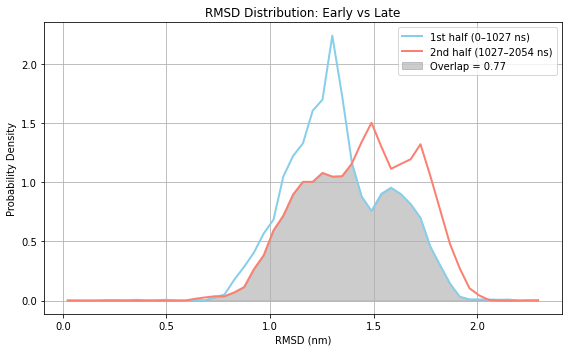

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Assume `rmsd` and `time` already exist
split_idx = len(rmsd) // 2
rmsd_early = rmsd[:split_idx]
rmsd_late = rmsd[split_idx:]

# Compute histogram bin edges
bins = np.linspace(min(rmsd.min(), rmsd_early.min(), rmsd_late.min()),
                   max(rmsd.max(), rmsd_early.max(), rmsd_late.max()), 50)

# Compute normalized histograms (PDFs)
hist_early, _ = np.histogram(rmsd_early, bins=bins, density=True)
hist_late, _ = np.histogram(rmsd_late, bins=bins, density=True)

# Compute bin centers for plotting
bin_centers = (bins[:-1] + bins[1:]) / 2

# Compute overlap
overlap = np.sum(np.minimum(hist_early, hist_late) * np.diff(bins))
print(f"Histogram Overlap: {overlap:.4f}")

# Plot histograms
plt.figure(figsize=(8, 5))
plt.plot(bin_centers, hist_early, label=f'1st half (0–{time[split_idx]:.0f} ns)', color='skyblue', lw=2)
plt.plot(bin_centers, hist_late, label=f'2nd half ({time[split_idx]:.0f}–{time[-1]:.0f} ns)', color='salmon', lw=2)
plt.fill_between(bin_centers, np.minimum(hist_early, hist_late), color='gray', alpha=0.4, label=f'Overlap = {overlap:.2f}')

plt.xlabel('RMSD (nm)')
plt.ylabel('Probability Density')
plt.title('RMSD Distribution: Early vs Late')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [40]:
sa_total_300K = np.sum(sa['rep:0'], axis=0)

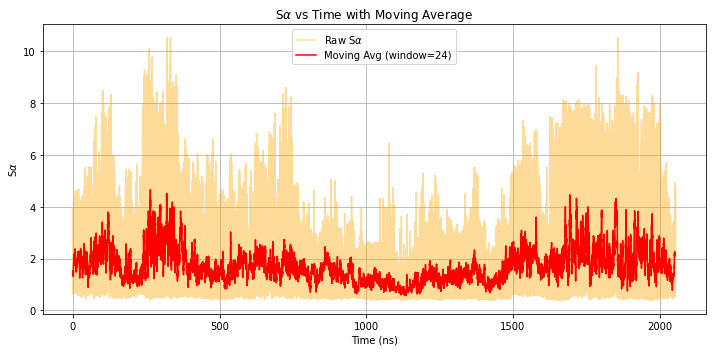

In [41]:
# Time axis (frames saved every 80 ps)
frame_interval_ps = 80
frame_interval_ns = frame_interval_ps / 1000
time = np.arange(len(sa_total_300K)) * frame_interval_ns

# Set window size for smoothing (e.g., 1 ns = 12 frames if 80 ps/frame)
#window_size = 12
window_size = 24

# Compute moving average of RMSD
sa_tot_smooth = np.convolve(sa_total_300K, np.ones(window_size)/window_size, mode='valid')
time_smooth = time[:len(sa_tot_smooth)]  # adjust time axis accordingly

# Plot
plt.figure(figsize=(10, 5))
plt.plot(time, sa_total_300K, color='orange', alpha=0.4, label=r'Raw S$\alpha$')
plt.plot(time_smooth, sa_tot_smooth, color='red', label=f'Moving Avg (window={window_size})')
plt.xlabel('Time (ns)')
plt.ylabel(r'S$\alpha$')
plt.title(r'S$\alpha$ vs Time with Moving Average')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

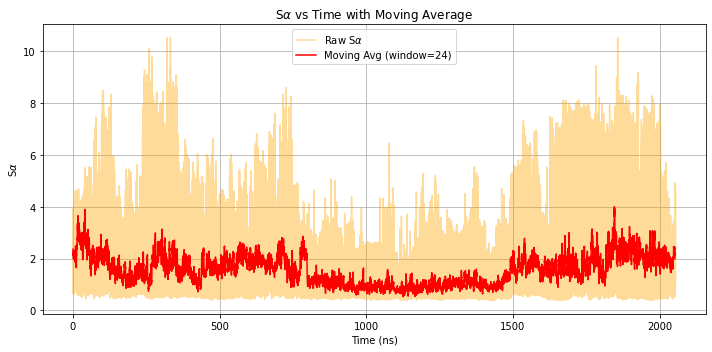

In [42]:
sa_total_dem = np.sum(sa['demux:0'], axis=0)
# sa_total_rep0 = np.sum(sa['rep:0'], axis=0)

# Time axis (frames saved every 80 ps)
frame_interval_ps = 80
frame_interval_ns = frame_interval_ps / 1000
time = np.arange(len(sa_total_dem)) * frame_interval_ns

# Set window size for smoothing (e.g., 1 ns = 12 frames if 80 ps/frame)
#window_size = 12
window_size = 24

# Compute moving average of RMSD
sa_tot_smooth = np.convolve(sa_total_dem, np.ones(window_size)/window_size, mode='valid')
time_smooth = time[:len(sa_tot_smooth)]  # adjust time axis accordingly

# Plot
plt.figure(figsize=(10, 5))
plt.plot(time, sa_total_300K, color='orange', alpha=0.4, label=r'Raw S$\alpha$')
plt.plot(time_smooth, sa_tot_smooth, color='red', label=f'Moving Avg (window={window_size})')
plt.xlabel('Time (ns)')
plt.ylabel(r'S$\alpha$')
plt.title(r'S$\alpha$ vs Time with Moving Average')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:

def pmf1d(x, nbins, range=None, weights=None, return_bin_centers=True):
    count, edge = np.histogram(x, bins=nbins, range=range, weights=weights)
    if weights is None:
        p = count / len(x)
    else:
        p = count
    if return_bin_centers:
        return p, edge[:-1] + np.diff(edge) / 2
    else:
        return p

def plot_rg_dist(rg_dict, nbins=50, outdir='.', cmap_name='tab20c', mode='rep'):


    # Filter keys based on mode
    if mode == 'rep':
        keys = [k for k in rg_dict.keys() if k.startswith('rep:')]
        title = 'Rg Distributions Across Temperature Replicas'
        filename = 'Rg_probabilities_reps.pdf'
    elif mode == 'demux':
        keys = [k for k in rg_dict.keys() if k.startswith('demux:')]
        title = 'Rg Distributions Across Demuxed Replicas'
        filename = 'Rg_probabilities_demux.pdf'
    else:
        raise ValueError("mode must be either 'rep' or 'demux'")

    keys.sort(key=lambda x: int(x.split(':')[1]))

    plt.figure(figsize=(8, 6))
    cmap = plt.cm.get_cmap(cmap_name, len(keys))
    colors = [cmap(i) for i in range(len(keys))]

    for i, key in enumerate(keys):
        x = rg_dict[key]
        p, bc = pmf1d(x, nbins=nbins)
        plt.plot(bc, p, color=colors[i], lw=2, label=key)

    plt.xlabel('Radius of Gyration [nm]', fontsize=14)
    plt.ylabel('Probability Density', fontsize=14)
    plt.title(title, fontsize=16)
    plt.legend(title='Replica', fontsize=10, title_fontsize=11, ncol=2, frameon=False)
    plt.tight_layout()
    plt.savefig(f"{outdir}/{filename}", bbox_inches='tight')
    plt.show()


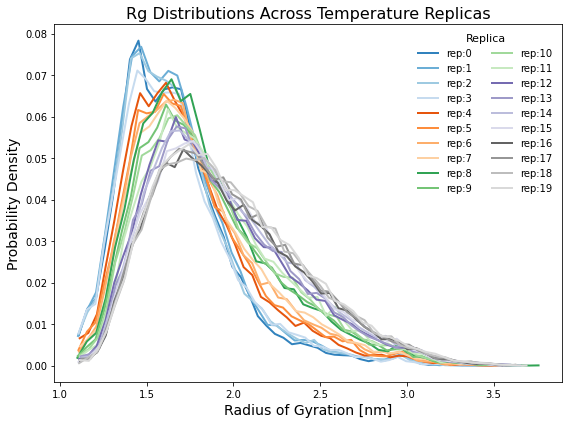

In [26]:
plot_rg_dist(rg, mode='rep')

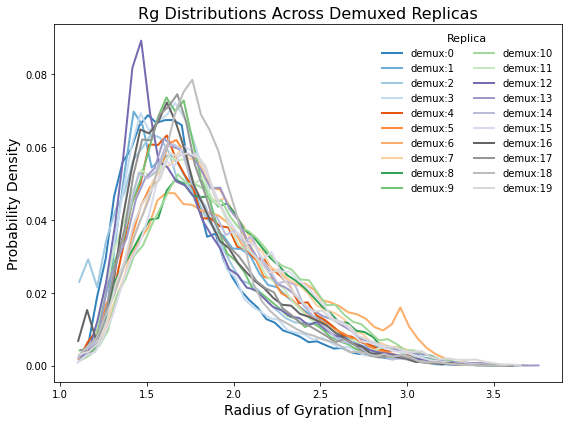

In [27]:
plot_rg_dist(rg, mode='demux')

{'whiskers': [<matplotlib.lines.Line2D at 0x7fc03344b550>,
 'caps': [<matplotlib.lines.Line2D at 0x7fbfd4c66750>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fbff7d92690>,
 'medians': [<matplotlib.lines.Line2D at 0x7fbfd4c66550>,
 'fliers': [<matplotlib.lines.Line2D at 0x7fbfd4c66790>,
 'means': []}

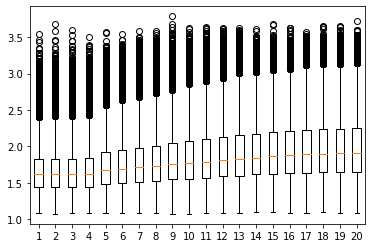

In [46]:
plt.boxplot([rg[key] for key in rg if 'rep' in key])

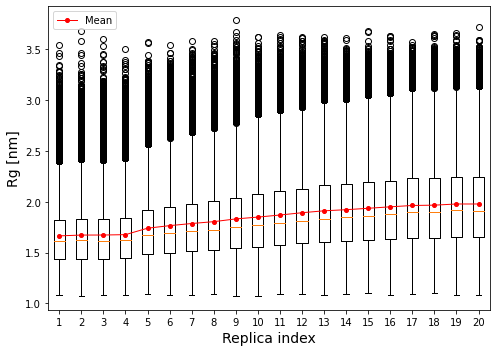

In [47]:
import numpy as np
import matplotlib.pyplot as plt


data = [rg[key] for key in rg if 'rep' in key]
plt.figure(figsize=(7,5))
plt.boxplot(data, showfliers=True)


means = [np.mean(x) for x in data]


plt.plot(range(1, len(means)+1), means, 'o-', color='red', lw=1, label='Mean', ms=4)

plt.xlabel('Replica index', fontsize=14)
plt.ylabel('Rg [nm]', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('rg_kappa_box.png', dpi=800)
plt.show()


In [48]:
replicas = np.linspace(0,19,20)


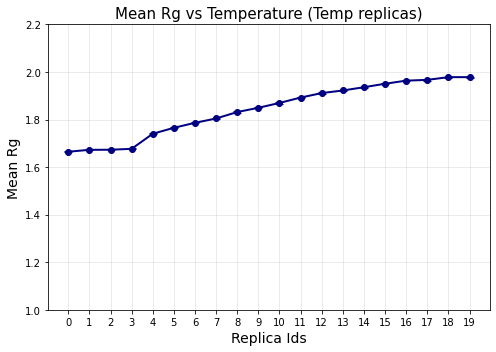

In [49]:
rg_list = [rg[key] for key in rg if 'rep' in key]
means = [np.mean(x) for x in rg_list]
sems = [np.std(x, ddof=1) / np.sqrt(len(x)) for x in rg_list]

# Plot
plt.figure(figsize=(7,5))
plt.errorbar(replicas, means, yerr=sems, fmt='o-', capsize=4, lw=2, color='navy')
plt.xlabel('Replica Ids', fontsize=14)
plt.ylabel('Mean Rg', fontsize=14)
plt.title('Mean Rg vs Temperature (Temp replicas)', fontsize=15)
plt.xticks(replicas)
plt.ylim(1.0, 2.2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('rg_400k_mean.png', dpi=800)
plt.show()

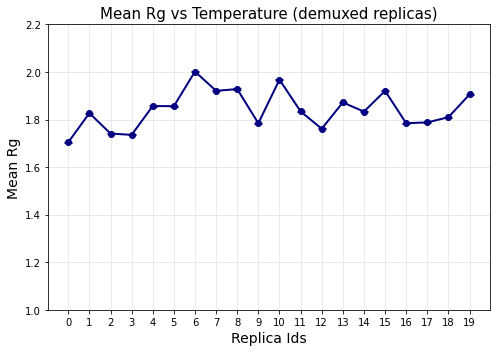

In [50]:
rg_list = [rg[key] for key in rg if 'demux' in key]

means = [np.mean(x) for x in rg_list]
sems = [np.std(x, ddof=1) / np.sqrt(len(x)) for x in rg_list]

# Plot
plt.figure(figsize=(7,5))
plt.errorbar(replicas, means, yerr=sems, fmt='o-', capsize=4, lw=2, color='navy')
plt.xlabel('Replica Ids', fontsize=14)
plt.ylabel('Mean Rg', fontsize=14)
plt.title('Mean Rg vs Temperature (demuxed replicas)', fontsize=15)
plt.xticks(replicas)
plt.ylim(1.0, 2.2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('rg_400k_mean.png', dpi=800)
plt.show()

(0.0, 0.3)

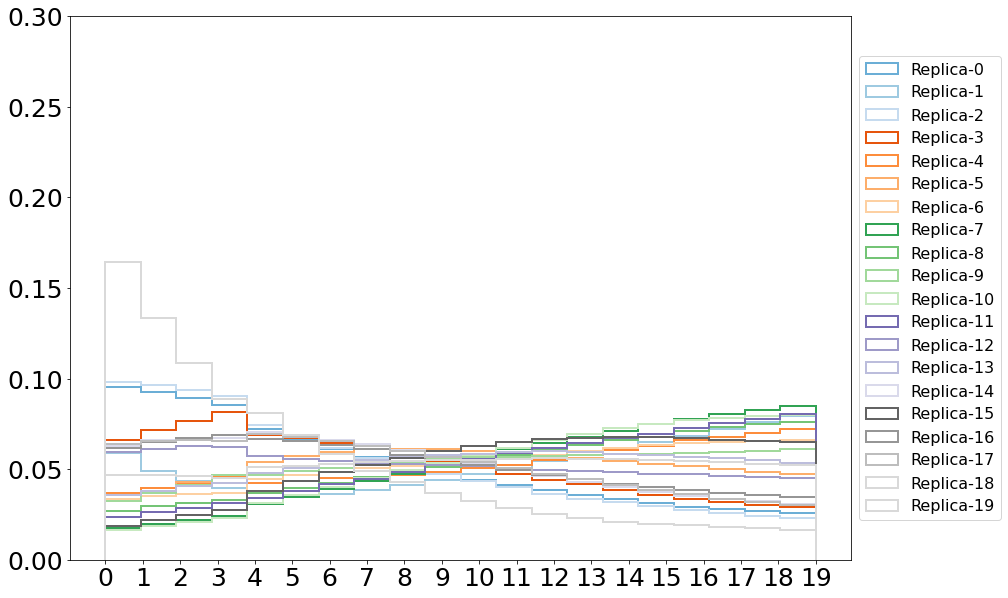

In [51]:
data={}
data['temp'] = np.loadtxt(dir + '/d/replica_temp.xvg', comments=['@','#'])
data['index'] = np.loadtxt(dir + '/d/replica_index.xvg', comments=['@','#'] )


nrep=20

plt.figure(figsize=(14,10))
for i in range(1,nrep+1):
    plt.hist(data['temp'].T[i],histtype='step',density='true',linewidth=2,
             color=plt.cm.tab20c(i),label='Replica-'+str(i-1),bins=nrep)
    
plt.tick_params(labelsize=25)
plt.xticks(range(nrep))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=16)
plt.ylim(0,0.3)

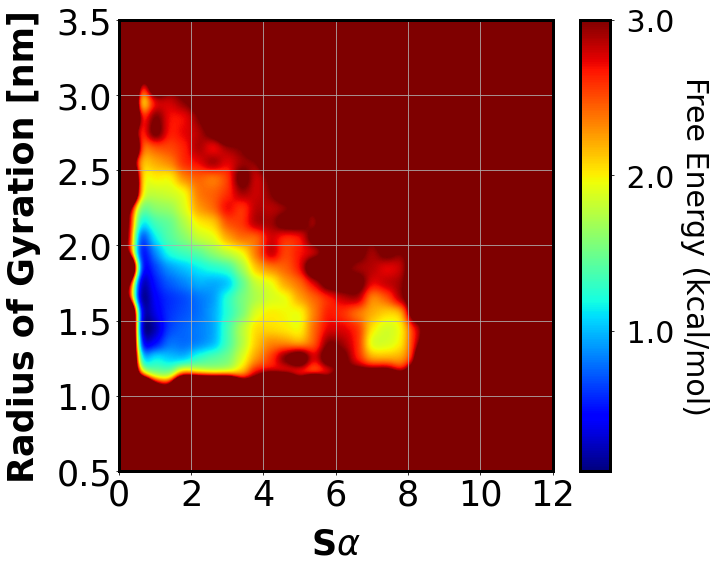

In [52]:
sa_total_rep0 = np.sum(sa['rep:0'], axis=0)


plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 3.0

def plot_Rg_vs_Sa(a, b, T, y0, ymax, x0, xmax, scatter_x=None, scatter_y=None, weight=None, title="", filename="plot.pdf"):
    # Calculate free energy
    free_energy, xedges, yedges = np.histogram2d(
        a, b, 30, [[y0, ymax], [x0, xmax]], density=True, weights=weight)
    free_energy = np.log(np.flipud(free_energy) + 0.000001)
    free_energy = -(0.001987 * T) * free_energy

    # Create and customize the plot
    fig = plt.figure(figsize=(10, 8))
    plt.scatter(scatter_x, scatter_y, marker='.', c='white', s=800, edgecolors='black', alpha=0.8)
    im = plt.imshow(free_energy, interpolation='gaussian', extent=[yedges[0], yedges[-1], xedges[0], xedges[-1]],
                    cmap='jet', aspect='auto')
    plt.title(title, fontsize=25, fontweight='bold', pad=20)
    cbar_ticks = [0, 1, 2, 3]
    cb = plt.colorbar(ticks=cbar_ticks, format=('% .1f'), aspect=15)
    cb.set_label("Free Energy (kcal/mol)", labelpad=35, fontsize=30, rotation=270)
    imaxes = plt.gca()
    plt.ylabel("Radius of Gyration [nm]", size=35, labelpad=15, fontweight='bold')
    plt.xlabel(r"S$\alpha$", size=35, labelpad=15, fontweight='bold')
    plt.xticks(fontsize=35)
    plt.yticks(fontsize=35)
    plt.grid()
    plt.xlim(0,12)
    plt.axes(cb.ax)
    plt.clim(vmin=0.1, vmax=3.0)
    cb.ax.tick_params(labelsize=30)
    

    file_path = os.path.join(outdir, filename)
    
    
    plt.tight_layout()
    plt.savefig(file_path)
    plt.show()
    
    

plot_Rg_vs_Sa(rg['rep:0'], sa_total_rep0, 300, 0.5, 3.5, 0, 12, scatter_x=None, scatter_y=None, weight=None, title='', filename='unbiased.rg_vs_sa.pdf')

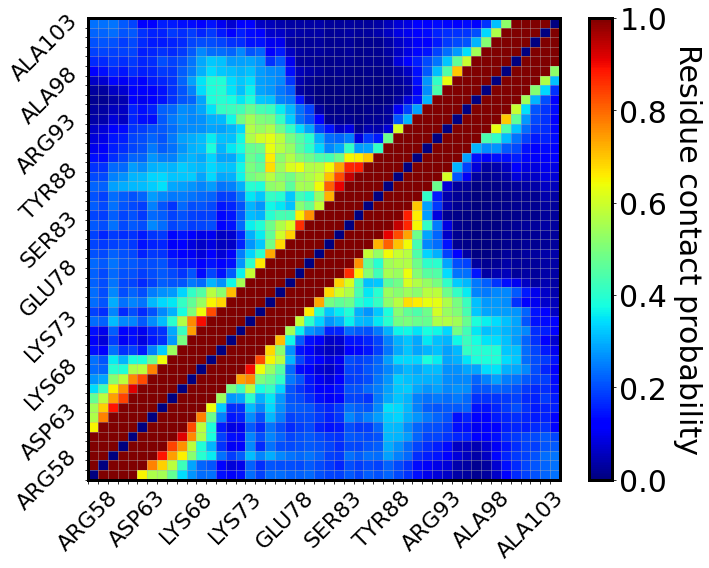

In [53]:
def plot_cmaps(map_data, residues, title=" ", filename=" "):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111)
    im = sns.heatmap(map_data, cmap='jet', ax=ax)
    ax.grid(which='both', alpha=0.5)

    # Determine number of residues
    nres = len(residues)

    # Safely handle sequence labels
    labels = [sequence[i] if i < len(sequence) else '' for i in range(nres)]

    plt.xticks(range(nres), labels, rotation=45, size=22)
    plt.yticks(range(nres), labels, rotation=45, size=22)

    cbar = im.collections[0].colorbar
    cbar.ax.tick_params(labelsize=30)
    cbar.set_label('Residue contact probability', labelpad=35, fontsize=30, rotation=270)
    ax.set_title(title, size=30, pad=20, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()

    # Outline for the axes and colorbar
    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(3)
    for _, spine in cbar.ax.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(3)

    filepath = os.path.join(outdir, filename)
    # plt.savefig(filepath)
    plt.show()

# call
plot_cmaps(contact_map_p['rep:0'], residues, title='', filename="prot_only_cmap.pdf")
